# Training - Quality Grader
Training a MobileNetV2 model to classify fruit/veg as fresh or rotten.
Using transfer learning since the model is already pretrained on ImageNet
so it already knows how to recognise visual features like edges, textures, colours etc.
I just need to teach it what fresh vs rotten looks like.

Then building a scoring layer on top to get the Color/Size/Ripeness scores
that the case study asks for.

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print(f'TF version: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

TF version: 2.19.0
GPU: []


In [34]:
# same extraction as the EDA notebook
ZIP_PATH = '/content/drive/MyDrive/Advanced_AI/archive.zip'
EXTRACT_TO = '/content/dataset'

if not os.path.exists(EXTRACT_TO):
    print('Extracting...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_TO)
    print('Done')
else:
    print('Already extracted')

Already extracted


In [35]:
def find_data_root(base_path):
    image_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    for root, dirs, files in os.walk(base_path):
        if any(Path(f).suffix.lower() in image_exts for f in files) and len(files) > 10:
            return str(Path(root).parent)
    return base_path

DATA_ROOT = find_data_root(EXTRACT_TO)
class_dirs = sorted([d for d in os.listdir(DATA_ROOT)
                     if os.path.isdir(os.path.join(DATA_ROOT, d)) and not d.startswith('.')])
print(f'Data root: {DATA_ROOT}, {len(class_dirs)} classes')

Data root: /content/dataset/Fruit And Vegetable Diseases Dataset, 28 classes


## Hyperparameters
putting all the settings here so its easy to change stuff if i need to retrain

In [36]:
IMG_SIZE = 224        # MobileNetV2 expects 224x224
BATCH_SIZE = 32
EPOCHS = 20           # early stopping will probably kick in before this
LEARNING_RATE = 0.0001
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15
RANDOM_STATE = 42

SAVE_DIR = '/content/drive/MyDrive/Advanced_AI'
os.makedirs(SAVE_DIR, exist_ok=True)

## Build the dataset
going through each folder and labelling every image as fresh (0) or rotten (1)
based on the folder name

In [37]:
image_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
records = []

for class_dir in class_dirs:
    class_path = os.path.join(DATA_ROOT, class_dir)
    dir_lower = class_dir.lower()

    if 'rotten' in dir_lower or 'stale' in dir_lower or 'diseased' in dir_lower:
        condition = 'rotten'
    else:
        condition = 'fresh'

    # extract produce name from folder
    produce = dir_lower
    for kw in ['rotten', 'stale', 'diseased', 'fresh', 'healthy', '_', '-']:
        produce = produce.replace(kw, ' ')
    produce = ' '.join(produce.split()).strip().title()

    for fname in os.listdir(class_path):
        if Path(fname).suffix.lower() in image_exts:
            records.append({
                'filepath': os.path.join(class_path, fname),
                'class_dir': class_dir,
                'produce': produce,
                'condition': condition,
                'binary_label': 0 if condition == 'fresh' else 1,
            })

df = pd.DataFrame(records)
print(f'{len(df)} images - Fresh: {(df.binary_label==0).sum()}, Rotten: {(df.binary_label==1).sum()}')

29291 images - Fresh: 13787, Rotten: 15504


## Train/val/test split
70/15/15 split, stratified so each split has the same proportion of each class

In [38]:
# hold out 15% for test first
train_val_df, test_df = train_test_split(
    df, test_size=TEST_SPLIT, random_state=RANDOM_STATE, stratify=df['class_dir']
)

# then split remaining into train and val
adjusted_val = VAL_SPLIT / (1 - TEST_SPLIT)
train_df, val_df = train_test_split(
    train_val_df, test_size=adjusted_val, random_state=RANDOM_STATE, stratify=train_val_df['class_dir']
)

print(f'Train: {len(train_df)} ({len(train_df)/len(df)*100:.0f}%)')
print(f'Val:   {len(val_df)} ({len(val_df)/len(df)*100:.0f}%)')
print(f'Test:  {len(test_df)} ({len(test_df)/len(df)*100:.0f}%)')

Train: 20503 (70%)
Val:   4394 (15%)
Test:  4394 (15%)


## Data augmentation
applying random transformations to training images to make the model more robust.
this helps prevent overfitting especially for the produce types with fewer images
(grapes, guava etc only have ~200 each).

using rotation, shifting, flipping, zoom and brightness changes - these are all
things that would naturally vary when a producer takes a photo of their produce
(different angles, lighting, distance etc). covered in week 3 lecture on augmentation.

In [39]:
# training data gets augmented, val and test dont
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=False,   # fruit doesnt get flipped upside down in real life
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

def make_generator(datagen, dataframe, shuffle=True):
    return datagen.flow_from_dataframe(
        dataframe=dataframe,
        x_col='filepath',
        y_col='condition',
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        classes=['fresh', 'rotten'],
        shuffle=shuffle
    )

train_gen = make_generator(train_datagen, train_df)
val_gen = make_generator(val_test_datagen, val_df, shuffle=False)
test_gen = make_generator(val_test_datagen, test_df, shuffle=False)

print(f'Classes: {train_gen.class_indices}')

Found 20495 validated image filenames belonging to 2 classes.
Found 4391 validated image filenames belonging to 2 classes.
Found 4391 validated image filenames belonging to 2 classes.
Classes: {'fresh': 0, 'rotten': 1}


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 8 invalid image filename(s) in x_col="filepath". These filename(s) will be ignored.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 3 invalid image filename(s) in x_col="filepath". These filename(s) will be ignored.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 3 invalid image filename(s) in x_col="filepath". These filename(s) will be ignored.
  warnings.warn(


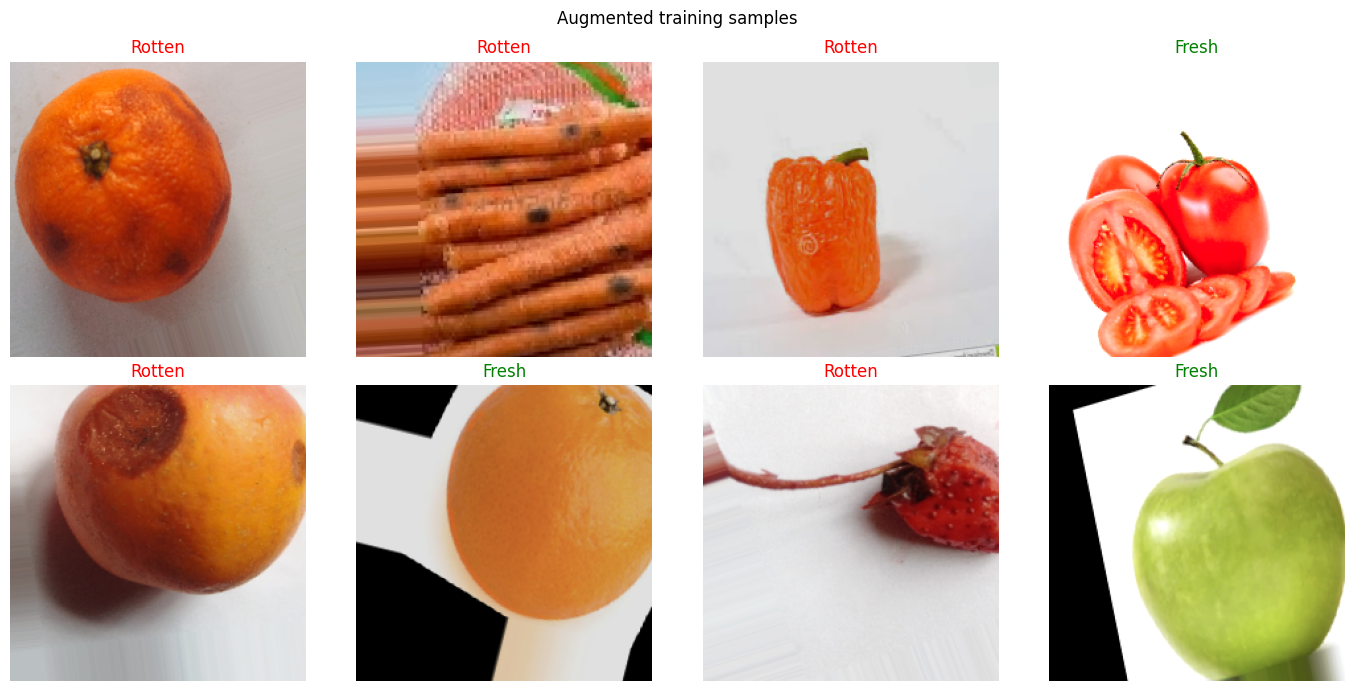

In [9]:
# quick look at what the augmented images look like
batch, labels = next(train_gen)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    if i < len(batch):
        ax.imshow(batch[i])
        ax.set_title('Fresh' if labels[i] == 0 else 'Rotten',
                     color='green' if labels[i] == 0 else 'red')
    ax.axis('off')
plt.suptitle('Augmented training samples')
plt.tight_layout()
plt.show()

## Build the model
using MobileNetV2 pretrained on ImageNet as the base. chose this over VGG16 (which we
covered in the transfer learning lecture) because its lighter and faster to train while
still getting good accuracy. also uses residual connections internally which helps with
the vanishing gradient problem (covered in the ResNet lecture).

the approach is:
1. freeze the pretrained base so its weights dont change
2. add a custom classification head on top
3. train just the head first (phase 1)
4. then unfreeze the top layers of the base and fine tune with a lower learning rate (phase 2)

In [10]:
# load MobileNetV2 without the top classification layer
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# freeze it so we dont mess up the pretrained weights
base_model.trainable = False

# add our own classification layers
inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)  # squash spatial dims into one vector
x = layers.Dropout(0.3)(x)               # helps prevent overfitting
x = layers.Dense(128, activation='relu', name='feature_layer')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation='sigmoid', name='classification')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification (Dense)          │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Phase 1 - train with frozen base
only training the classification head here, the MobileNetV2 base stays frozen.
using early stopping so it doesnt keep going if accuracy plateaus

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint(
        filepath=os.path.join(SAVE_DIR, 'best_model_phase1.keras'),
        monitor='val_accuracy', save_best_only=True, verbose=1
    )
]

history_phase1 = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks
)

In [ ]:
def plot_training(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].plot(history.history['accuracy'], label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Val')
    axes[0].set_title('Accuracy')
    axes[0].legend()
    axes[1].plot(history.history['loss'], label='Train')
    axes[1].plot(history.history['val_loss'], label='Val')
    axes[1].set_title('Loss')
    axes[1].legend()
    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'{title.lower().replace(" ", "_")}.png'), dpi=150)
    plt.show()

plot_training(history_phase1, 'Phase 1 - Frozen Base')

## Phase 2 - fine tuning
now unfreezing the top layers of MobileNetV2 and training them with a much
lower learning rate. this adapts the pretrained features specifically to fruit/veg
images rather than just using the generic ImageNet features.

need a lower LR here because we dont want to destroy the useful pretrained weights,
just nudge them slightly towards our specific task

In [ ]:
FINE_TUNE_FROM = 100  # unfreeze layers 100 onwards (54 layers)

base_model.trainable = True
for layer in base_model.layers[:FINE_TUNE_FROM]:
    layer.trainable = False

print(f'Unfroze {sum(1 for l in base_model.layers if l.trainable)} of {len(base_model.layers)} layers')

# recompile with lower learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks_p2 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-8, verbose=1),
    ModelCheckpoint(
        filepath=os.path.join(SAVE_DIR, 'best_model_phase2.keras'),
        monitor='val_accuracy', save_best_only=True, verbose=1
    )
]

history_phase2 = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks_p2
)

plot_training(history_phase2, 'Phase 2 - Fine Tuning')

## Evaluate on test set
these images were held out completely - the model has never seen them

In [40]:
from tensorflow.keras.models import load_model
model = load_model('/content/drive/MyDrive/Advanced_AI/best_model_phase2.keras')
print('Phase 2 loaded')

Phase 2 loaded


In [41]:
test_gen.reset()
test_loss, test_acc = model.evaluate(test_gen)
print(f'\nTest accuracy: {test_acc:.4f}')
print(f'Test loss: {test_loss:.4f}')

138/138 ━━━━━━━━━━━━━━━━━━━━ 241s 2s/step - accuracy: 0.9968 - loss: 0.0122

Test accuracy: 0.9968
Test loss: 0.0122


In [42]:
test_gen.reset()
y_pred_probs = model.predict(test_gen)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = test_gen.classes

print(classification_report(y_true, y_pred, target_names=['Fresh', 'Rotten']))

138/138 ━━━━━━━━━━━━━━━━━━━━ 226s 2s/step
              precision    recall  f1-score   support

       Fresh       1.00      1.00      1.00      2066
      Rotten       1.00      1.00      1.00      2325

    accuracy                           1.00      4391
   macro avg       1.00      1.00      1.00      4391
weighted avg       1.00      1.00      1.00      4391



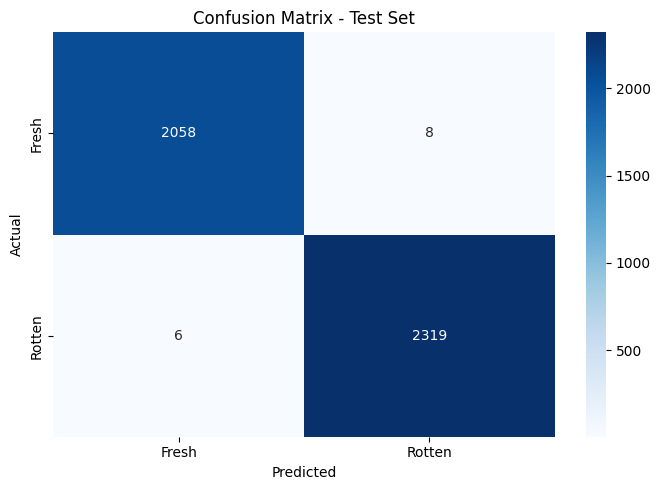

Fresh accuracy:  0.996
Rotten accuracy: 0.997


In [43]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fresh', 'Rotten'],
            yticklabels=['Fresh', 'Rotten'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

print(f'Fresh accuracy:  {cm[0,0]/cm[0].sum():.3f}')
print(f'Rotten accuracy: {cm[1,1]/cm[1].sum():.3f}')

## Quality scoring layer
the case study wants Color %, Size %, Ripeness % scores leading to a grade.
but the dataset only has fresh/rotten labels so i need to derive these scores
from the image properties and the models prediction.

- **Color**: using HSV saturation to measure how vibrant the colours are.
  fresh produce tends to have more saturated colours, rotten goes dull/brown.
- **Size**: using foreground segmentation to see how much of the image the
  produce fills. otsu thresholding to separate produce from background.
- **Ripeness**: combining the models confidence (how sure it is the item is
  fresh) with colour warmth (warm colours = ripe, dark = over-ripe).

Thresholds from the case study:
- Grade A: Color >= 75%, Size >= 80%, Ripeness >= 70%
- Grade B: Color >= 65%, Size >= 70%, Ripeness >= 60%
- Grade C: below B thresholds

In [47]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import cv2


def compute_color_score(img_array, fresh_confidence=None):
    """colour vibrancy score using HSV saturation"""
    img_uint8 = (img_array * 255).astype(np.uint8)
    hsv = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2HSV)

    saturation = hsv[:, :, 1].mean() / 255.0
    value = hsv[:, :, 2].mean() / 255.0
    brightness_penalty = 1.0 - abs(value - 0.55) * 0.5

    raw_score = (saturation * 0.7 + brightness_penalty * 0.3)
    score = raw_score * 120

    # blend with model confidence so naturally pale produce like bananas
    # dont get penalised just for being yellow
    if fresh_confidence is not None:
        score = score * 0.5 + fresh_confidence * 100 * 0.5

    return round(float(np.clip(score, 0, 100)), 1)


def compute_size_score(img_array):
    """how much of the frame the produce fills"""
    img_uint8 = (img_array * 255).astype(np.uint8)
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)

    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    fg_ratio = np.count_nonzero(binary) / binary.size

    if fg_ratio < 0.2:
        score = fg_ratio / 0.2 * 60
    elif fg_ratio > 0.85:
        score = 85 - (fg_ratio - 0.85) * 100
    else:
        score = 70 + (fg_ratio - 0.2) / 0.5 * 30

    return round(float(np.clip(score, 0, 100)), 1)


def compute_ripeness_score(img_array, fresh_confidence):
    """combines model confidence with colour warmth"""
    r_mean = img_array[:, :, 0].mean()
    g_mean = img_array[:, :, 1].mean()
    b_mean = img_array[:, :, 2].mean()

    warmth = (r_mean + g_mean * 0.5) / (b_mean + 0.01)
    warmth_normalised = np.clip(warmth / 4.0, 0, 1)

    raw_score = fresh_confidence * 0.6 + warmth_normalised * 0.4
    score = np.clip(raw_score * 100, 0, 100)
    return round(float(score), 1)


def assign_grade(color_score, size_score, ripeness_score):
    """grade based on case study thresholds"""
    if color_score >= 75 and size_score >= 80 and ripeness_score >= 70:
        return 'A'
    elif color_score >= 65 and size_score >= 70 and ripeness_score >= 60:
        return 'B'
    else:
        return 'C'


def grade_image(filepath, model):
    """full grading pipeline for one image"""
    img = load_img(filepath, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img) / 255.0

    pred_input = np.expand_dims(img_array, axis=0)
    rotten_prob = float(model.predict(pred_input, verbose=0)[0][0])
    fresh_conf = 1.0 - rotten_prob

    color = compute_color_score(img_array, fresh_conf)
    size = compute_size_score(img_array)
    ripeness = compute_ripeness_score(img_array, fresh_conf)
    grade = assign_grade(color, size, ripeness)

    return {
        'prediction': 'Fresh' if fresh_conf > 0.5 else 'Rotten',
        'confidence': max(fresh_conf, rotten_prob),
        'color_score': color,
        'size_score': size,
        'ripeness_score': ripeness,
        'grade': grade
    }

## Test the grading
running it on some sample images to see if the grades make sense

In [48]:
sample_fresh = test_df[test_df['condition'] == 'fresh'].sample(6, random_state=42)
sample_rotten = test_df[test_df['condition'] == 'rotten'].sample(6, random_state=42)
samples = pd.concat([sample_fresh, sample_rotten])

results = []
for _, row in samples.iterrows():
    result = grade_image(row['filepath'], model)
    result['actual'] = row['condition']
    result['produce'] = row['produce']
    result['filepath'] = row['filepath']  # keep this for the visualisation
    results.append(result)

results_df = pd.DataFrame(results)
print(results_df[['produce', 'actual', 'prediction', 'confidence',
                   'color_score', 'size_score', 'ripeness_score', 'grade']].to_string(index=False))

   produce actual prediction  confidence  color_score  size_score  ripeness_score grade
     Apple  fresh      Fresh    0.999650         78.0        89.9            79.8     A
     Grape  fresh      Fresh    0.999984         84.1        94.6            75.5     A
    Jujube  fresh      Fresh    0.999540         72.5        79.9            76.1     B
    Orange  fresh      Fresh    0.997200         88.2       100.0            92.9     A
    Banana  fresh      Fresh    0.999999         71.6       100.0            77.2     B
    Banana  fresh      Fresh    0.999297         74.1       100.0            78.2     B
    Banana rotten     Rotten    0.999981         20.5       100.0            15.8     C
    Orange rotten     Rotten    0.999968         34.5        96.9            31.2     C
    Tomato rotten     Rotten    1.000000         22.2       100.0            16.9     C
     Apple rotten     Rotten    0.999998         33.7        89.1            19.7     C
Bellpepper rotten      Fresh    

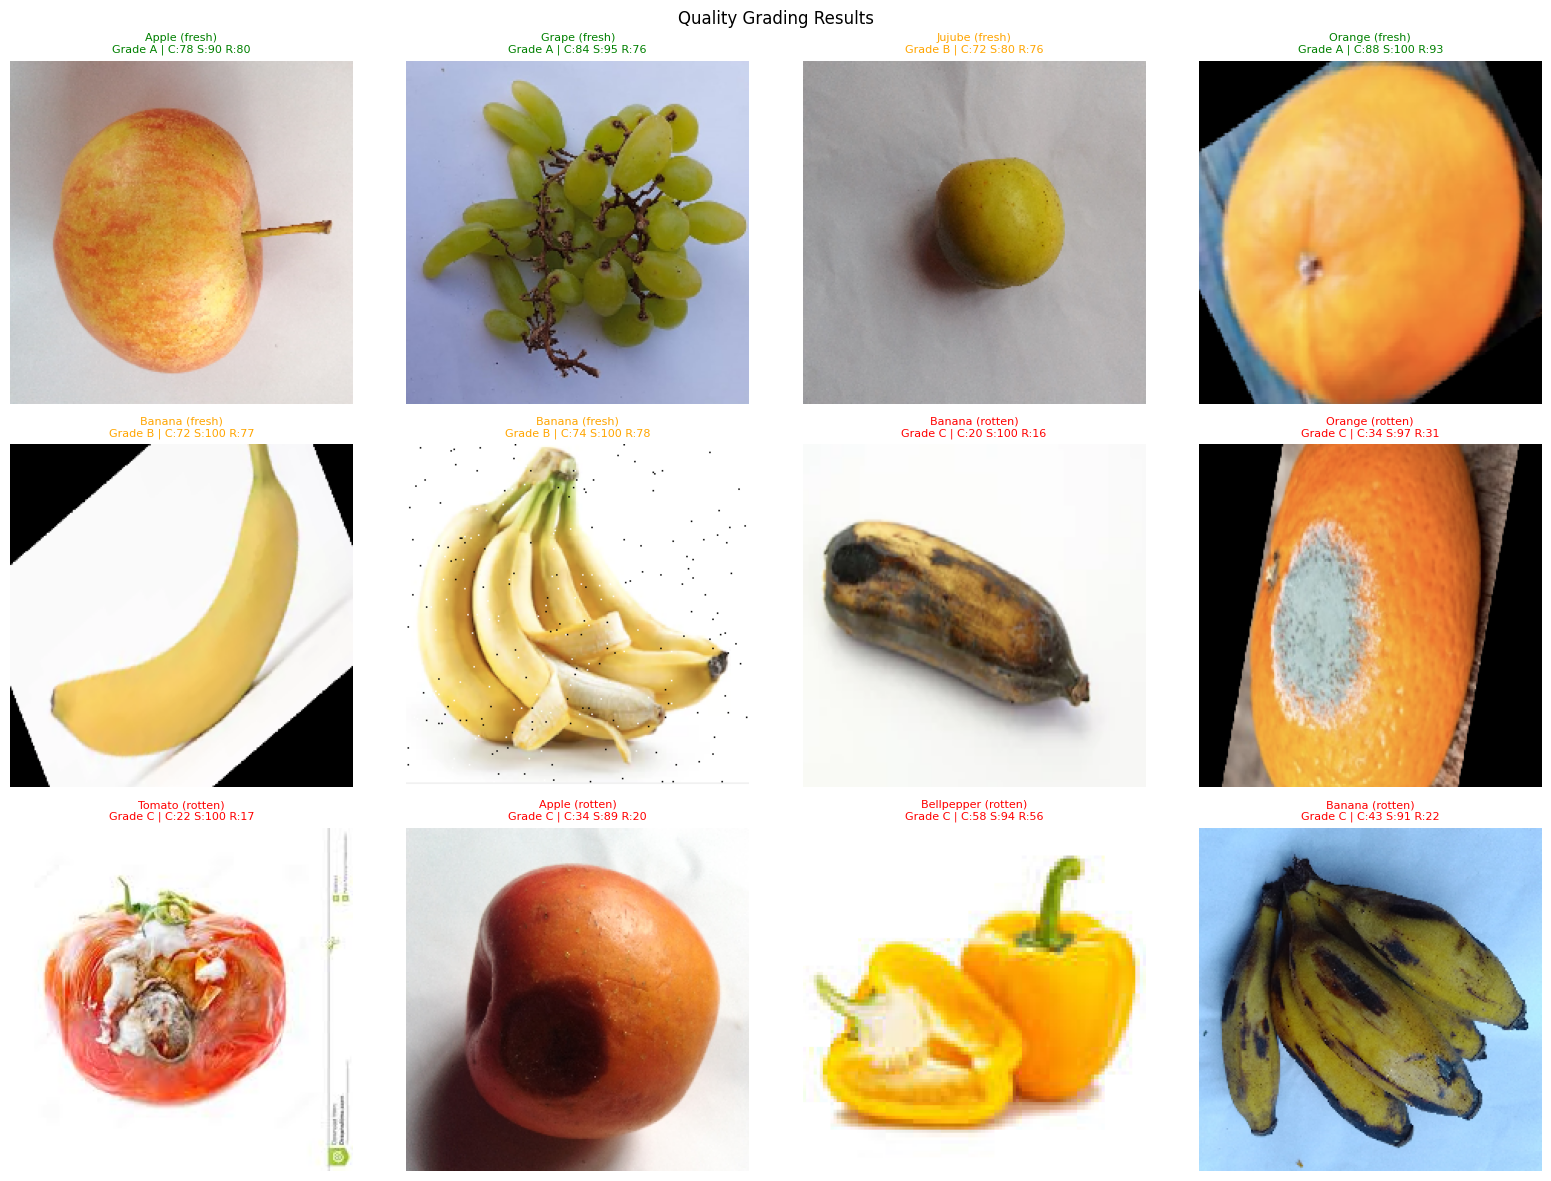

In [49]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

grade_colors = {'A': 'green', 'B': 'orange', 'C': 'red'}

for i, result in enumerate(results):
    ax = axes[i // 4, i % 4]
    img = load_img(result['filepath'], target_size=(IMG_SIZE, IMG_SIZE))
    ax.imshow(img)
    ax.set_title(
        f"{result['produce']} ({result['actual']})\n"
        f"Grade {result['grade']} | C:{result['color_score']:.0f} S:{result['size_score']:.0f} R:{result['ripeness_score']:.0f}",
        fontsize=8, color=grade_colors[result['grade']]
    )
    ax.axis('off')

plt.suptitle('Quality Grading Results')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'grading_results.png'), dpi=150)
plt.show()

## Save the model
saving to drive so it persists. this is the file that gets given to
callum for the FastAPI service and aaron for XAI

In [ ]:
import json

# save the model in both formats
model.save(os.path.join(SAVE_DIR, 'quality_grader_mobilenetv2.keras'))
model.save(os.path.join(SAVE_DIR, 'quality_grader_mobilenetv2.h5'))

# save some metadata about the model
metadata = {
    'model_name': 'quality_grader_mobilenetv2',
    'base_model': 'MobileNetV2',
    'input_size': IMG_SIZE,
    'classes': ['fresh', 'rotten'],
    'test_accuracy': float(test_acc),
    'test_loss': float(test_loss),
    'training_samples': int(train_gen.samples),
    'fine_tune_from_layer': FINE_TUNE_FROM,
    'grading_thresholds': {
        'A': {'color': 75, 'size': 80, 'ripeness': 70},
        'B': {'color': 65, 'size': 70, 'ripeness': 60},
        'C': 'below B'
    }
}

with open(os.path.join(SAVE_DIR, 'model_metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

print('Model and metadata saved')
print(json.dumps(metadata, indent=2))

## Done

trained a MobileNetV2 model with transfer learning to classify fruit/veg as fresh or rotten.
two phase training - frozen base first then fine tuned the top layers.
built a quality scoring layer that derives Color, Size and Ripeness scores from
the image properties and model confidence, then assigns a grade A/B/C based on
the thresholds in the case study.

model saved to drive as .keras and .h5 files for the rest of the team to use.